# Bank Marketing - Feature Engineering

**DATA 4950 Week 7 Demo**

## What We Will Cover
1. Load preprocessed data
2. Create new features (ratios, bins, interactions)
3. Encode categorical features
4. Scale numerical features
5. Feature selection
6. Handle class imbalance (SMOTE)
7. Save final data for modeling

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## 1. Load and Quick Prep

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 32,940 rows x 19 columns
y_train Loaded: 32,940 rows x 1 columns
X_test Loaded: 8,236 rows x 19 columns
y_test Loaded: 8,236 rows x 1 columns


In [3]:
X_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,48,technician,married,professional.course,no,yes,no,cellular,jul,mon,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
1,45,blue-collar,single,high.school,unknown,yes,no,cellular,may,mon,6,999,1,failure,-1.8,92.893,-46.2,1.244,5099.1
2,40,admin.,married,university.degree,no,no,no,cellular,aug,wed,2,999,1,failure,-2.9,92.201,-31.4,0.884,5076.2
3,47,retired,single,basic.6y,unknown,no,no,cellular,jul,mon,5,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
4,56,blue-collar,married,high.school,unknown,yes,no,telephone,jun,fri,3,999,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1


In [4]:
## check column types

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

Numerical (9): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [5]:
y_train

,y
0,1
1,0
2,0
3,0
4,0
...,...
32935,0
32936,0
32937,0
32938,1


## 2. Create New Features

Feature engineering adds **domain knowledge** to help the model.  
We create features on both train and test using the **same logic**.

### 2.1 Binning — Age Groups

In [6]:
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['young', 'middle', 'senior', 'older', 'olderly']

# TODO: create age groups
X_train['age_groups'] = pd.cut(X_train['age'], bins= age_bins, labels=age_labels)
print('Age groups created:')
print(X_train['age_groups'].value_counts().sort_index())

Age groups created:
age_groups
young       5978
middle     13062
senior      8197
older       4974
olderly      729
Name: count, dtype: int64


In [7]:
X_test['age_groups'] = pd.cut(X_test['age'], bins= age_bins, labels=age_labels)
print(X_test['age_groups'].value_counts().sort_index())

age_groups
young      1403
middle     3318
senior     2040
older      1295
olderly     180
Name: count, dtype: int64


### 2.2 Ratio Features

In [8]:
# TODO: campaign intensity: how many calls relative to previous campaigns
# campaign_intensity = campaign /(previous +1 )

X_train['campaign_intensity'] = X_train['campaign']/(X_train['previous']+1)
X_test['campaign_intensity'] = X_test['campaign']/(X_test['previous']+1)

print('Create: campaign_intensity')
print(f'Mean: {X_train['campaign_intensity'].mean():.2f}')

Create: campaign_intensity
Mean: 2.13


### 2.3 Interaction Features

In [9]:
# economic pressure: combine employment rate with consumer confidence

X_train['econ_pressure'] = X_train['emp.var.rate']*X_train['cons.conf.idx']
X_test['econ_pressure'] = X_test['emp.var.rate']*X_test['cons.conf.idx']

print('Create: econ_pressure')

Create: econ_pressure


In [10]:
## TODO: contact vs economic conditions
# campaign x euribor3m

X_train['campaign_x_euribor'] = X_train['campaign']*X_train['euribor3m']
X_test['campaign_x_euribor'] = X_test['campaign']*X_test['euribor3m']


print('Create: campaign_x_euribor')

Create: campaign_x_euribor


### 2.4 Flag Features

Create binary (0/1) flags

In [11]:
## was client contacted before? (pdays=999 means never contacted)

X_train['was_contacted_before'] = (X_train['pdays']!=999).astype(int)
X_test['was_contacted_before'] = (X_test['pdays']!=999).astype(int)

print('Create: was_contacted_before')
print(f'Previously contacted: {X_train['was_contacted_before'].mean()*100:.1f}%')

Create: was_contacted_before
Previously contacted: 3.7%


In [12]:
# TODO: many campaign contacts (contacted more than 3 times)

X_train['many_contacts'] = (X_train['campaign']>3).astype(int)
X_test['many_contacts'] = (X_test['campaign']>3).astype(int)

print('Create: many_contacts')
print(f'Previously contacted: {X_train['many_contacts'].mean()*100:.1f}%')

Create: many_contacts
Previously contacted: 18.6%


#### 2.5 Log Transform

Skewed features

In [13]:
## log transform of campaign
log_campaign1 = np.log1p(X_train['campaign'])
log_campaign2 = np.log(X_train['campaign']+1)
print(f'difference: {((log_campaign1-log_campaign2)**2).sum()}')

difference: 0.0


In [14]:
X_train['log_campaign'] = np.log1p(X_train['campaign'])

print('Created: log_campaign')

Created: log_campaign


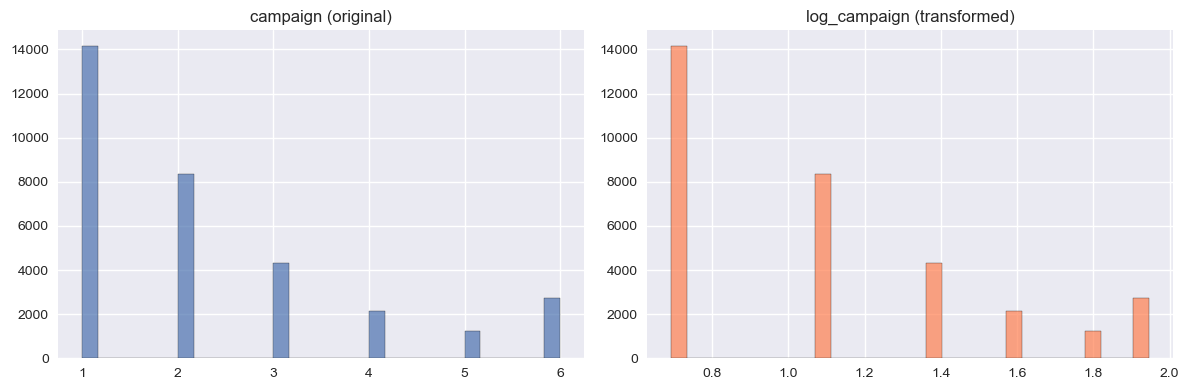

In [15]:
# compare original vs log transform

fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].hist(X_train['campaign'],bins=30,edgecolor='black',alpha=0.7)
axes[0].set_title('campaign (original)')

axes[1].hist(X_train['log_campaign'],bins=30,edgecolor='black',alpha=0.7, color='coral')
axes[1].set_title('log_campaign (transformed)')
plt.tight_layout()
plt.show()

In [16]:
X_train = X_train.drop(['log_campaign'],axis=1)

In [17]:
new_features = ['age_grouped','campaign_intensity','econ_pressure','campaign_x_euribor',
               'was_contacted_before','many_contacts']

print(f'Created {len(new_features)} new features:')
for f in new_features:
    print(f'{f}')


print(f'\nTotal features now: {X_train.shape[1]}')

Created 6 new features:
age_grouped
campaign_intensity
econ_pressure
campaign_x_euribor
was_contacted_before
many_contacts

Total features now: 25


### 3. Encode Categorical Features

Convert categorical columns to numbers so the model can use them.

**Strategy:**
- **Ordinal encoding** for features with natural order (education)
- **One-hot encoding** for nominal features (no natural order)

In [18]:
# check categorical columns
for col in categorical_cols:
    print(f'{col}: {X_train[col].nunique()} unique -> {X_train[col].unique()}')

job: 11 unique -> ['technician' 'blue-collar' 'admin.' 'retired' 'management'
 'self-employed' 'services' 'student' 'entrepreneur' 'housemaid'
 'unemployed']
marital: 3 unique -> ['married' 'single' 'divorced']
education: 7 unique -> ['professional.course' 'high.school' 'university.degree' 'basic.6y'
 'basic.9y' 'basic.4y' 'illiterate']
default: 3 unique -> ['no' 'unknown' 'yes']
housing: 2 unique -> ['yes' 'no']
loan: 2 unique -> ['no' 'yes']
contact: 2 unique -> ['cellular' 'telephone']
month: 10 unique -> ['jul' 'may' 'aug' 'jun' 'nov' 'sep' 'oct' 'mar' 'apr' 'dec']
day_of_week: 5 unique -> ['mon' 'wed' 'fri' 'tue' 'thu']
poutcome: 3 unique -> ['nonexistent' 'failure' 'success']


#### 3.1 Ordinal Encoding - Education

In [19]:
X_train['education'].value_counts()

education
university.degree      11071
high.school             7626
basic.9y                4846
professional.course     4165
basic.4y                3359
basic.6y                1859
illiterate                14
Name: count, dtype: int64

In [20]:
## TODO: Ordinal encoding for education

X_train['education'] = X_train['education'].replace('illiterate', 'basic.4y')
X_test['education'] = X_test['education'].replace('illiterate', 'basic.4y')

education_order =['basic.4y', 'basic.6y', 'basic.9y', 'high.school',
                  'professional.course'  ,'university.degree']

In [21]:
from sklearn.preprocessing import OrdinalEncoder


ord_encoder = OrdinalEncoder(categories=[education_order],handle_unknown='use_encoded_value',
                            unknown_value=-1)

X_train['education_encoded'] = ord_encoder.fit_transform(X_train[['education']])
X_test['education_encoded'] = ord_encoder.transform(X_test[['education']])

print('Education encoding:')
for i, level in enumerate(education_order):
    print(f'{level} -> {i}')

Education encoding:
basic.4y -> 0
basic.6y -> 1
basic.9y -> 2
high.school -> 3
professional.course -> 4
university.degree -> 5


#### 3.2 One-Hot Encoding - Nominal Categories

In [22]:
X_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,age_groups,campaign_intensity,econ_pressure,campaign_x_euribor,was_contacted_before,many_contacts,education_encoded
0,48,technician,married,professional.course,no,yes,no,cellular,jul,mon,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,senior,2.0,-59.78,9.924,0,0,4.0
1,45,blue-collar,single,high.school,unknown,yes,no,cellular,may,mon,6,999,1,failure,-1.8,92.893,-46.2,1.244,5099.1,senior,3.0,83.16,7.464,0,1,3.0
2,40,admin.,married,university.degree,no,no,no,cellular,aug,wed,2,999,1,failure,-2.9,92.201,-31.4,0.884,5076.2,middle,1.0,91.06,1.768,0,0,5.0
3,47,retired,single,basic.6y,unknown,no,no,cellular,jul,mon,5,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,senior,5.0,-59.78,24.810,0,1,1.0
4,56,blue-collar,married,high.school,unknown,yes,no,telephone,jun,fri,3,999,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1,older,3.0,-58.52,14.901,0,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32935,45,technician,single,university.degree,no,no,no,cellular,nov,fri,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,senior,2.0,4.20,8.042,0,0,5.0
32936,51,technician,married,professional.course,no,no,no,telephone,may,wed,2,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,older,2.0,-40.04,9.718,0,0,4.0
32937,40,admin.,single,high.school,no,yes,no,telephone,may,wed,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,middle,3.0,-40.04,14.571,0,0,3.0
32938,56,admin.,married,university.degree,no,no,no,telephone,oct,fri,1,999,0,nonexistent,-0.1,93.798,-40.4,5.045,5195.8,older,1.0,4.04,5.045,0,0,5.0


In [23]:
nominal_cols = []
for col in categorical_cols:
    if col!='education':
        nominal_cols.append(col)

nominal_cols.append('age_groups')
print(f'nomical columns: {nominal_cols}')

nomical columns: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_groups']


In [24]:
# apply one-hot encoding using pd.get_dummies
# drop_first=True to avoid multicollinearity (dummy variable trap)


# For X_train
job_dummies_train = pd.get_dummies(X_train['job'], prefix='job', drop_first=True,dtype=int)
job_dummies_train

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
32935,0,0,0,0,0,0,0,0,1,0
32936,0,0,0,0,0,0,0,0,1,0
32937,0,0,0,0,0,0,0,0,0,0
32938,0,0,0,0,0,0,0,0,0,0


In [25]:
X_train_example = pd.concat([X_train, job_dummies_train], axis=1)
X_train_example = X_train_example.drop('job', axis=1)
X_train_example

,age,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,age_groups,campaign_intensity,econ_pressure,campaign_x_euribor,was_contacted_before,many_contacts,education_encoded,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,48,married,professional.course,no,yes,no,cellular,jul,mon,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,senior,2.0,-59.78,9.924,0,0,4.0,0,0,0,0,0,0,0,0,1,0
1,45,single,high.school,unknown,yes,no,cellular,may,mon,6,999,1,failure,-1.8,92.893,-46.2,1.244,5099.1,senior,3.0,83.16,7.464,0,1,3.0,1,0,0,0,0,0,0,0,0,0
2,40,married,university.degree,no,no,no,cellular,aug,wed,2,999,1,failure,-2.9,92.201,-31.4,0.884,5076.2,middle,1.0,91.06,1.768,0,0,5.0,0,0,0,0,0,0,0,0,0,0
3,47,single,basic.6y,unknown,no,no,cellular,jul,mon,5,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,senior,5.0,-59.78,24.810,0,1,1.0,0,0,0,0,1,0,0,0,0,0
4,56,married,high.school,unknown,yes,no,telephone,jun,fri,3,999,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1,older,3.0,-58.52,14.901,0,0,3.0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32935,45,single,university.degree,no,no,no,cellular,nov,fri,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,senior,2.0,4.20,8.042,0,0,5.0,0,0,0,0,0,0,0,0,1,0
32936,51,married,professional.course,no,no,no,telephone,may,wed,2,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,older,2.0,-40.04,9.718,0,0,4.0,0,0,0,0,0,0,0,0,1,0
32937,40,single,high.school,no,yes,no,telephone,may,wed,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,middle,3.0,-40.04,14.571,0,0,3.0,0,0,0,0,0,0,0,0,0,0
32938,56,married,university.degree,no,no,no,telephone,oct,fri,1,999,0,nonexistent,-0.1,93.798,-40.4,5.045,5195.8,older,1.0,4.04,5.045,0,0,5.0,0,0,0,0,0,0,0,0,0,0


In [26]:
# TODO: For X_test (same steps)
job_dummies_test = pd.get_dummies(X_test['job'], prefix='job', drop_first=True,dtype=int)
X_test_example = pd.concat([X_test, job_dummies_test], axis=1)
X_test_example = X_test_example.drop('job', axis=1)
X_test_example

,age,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,age_groups,campaign_intensity,econ_pressure,campaign_x_euribor,was_contacted_before,many_contacts,education_encoded,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,59,married,university.degree,unknown,yes,no,cellular,aug,tue,2,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,older,2.0,-50.54,9.930,0,0,5.0,0,0,1,0,0,0,0,0,0,0
1,48,married,university.degree,no,no,no,cellular,aug,tue,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,senior,2.0,-50.54,9.926,0,0,5.0,0,0,0,1,0,0,0,0,0,0
2,28,married,high.school,no,no,no,cellular,nov,tue,2,999,0,nonexistent,-3.4,92.649,-30.1,0.715,5017.5,young,2.0,102.34,1.430,0,0,3.0,0,0,0,0,0,0,0,0,0,0
3,26,single,high.school,no,yes,no,cellular,jul,wed,6,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,young,6.0,-59.78,29.778,0,1,3.0,0,0,0,0,0,0,1,0,0,0
4,50,married,university.degree,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1,senior,1.0,-58.52,4.864,0,0,5.0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8231,32,single,university.degree,no,yes,no,cellular,jul,fri,1,999,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1,middle,1.0,-59.78,4.957,0,0,5.0,0,0,0,0,0,0,0,0,0,0
8232,59,divorced,basic.6y,unknown,yes,no,cellular,may,tue,1,999,0,nonexistent,-1.8,92.893,-46.2,1.291,5099.1,older,1.0,83.16,1.291,0,0,1.0,0,0,1,0,0,0,0,0,0,0
8233,35,married,university.degree,no,yes,no,cellular,may,mon,3,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,middle,3.0,83.16,3.897,0,0,5.0,0,0,0,0,0,0,0,0,1,0
8234,49,single,high.school,no,yes,no,telephone,nov,fri,2,999,1,failure,-0.1,93.200,-42.0,4.021,5195.8,senior,1.0,4.20,8.042,0,0,3.0,0,0,0,0,0,0,0,0,0,1


In [27]:
## TODO: multi-columns one-hot encoding

X_train = pd.get_dummies(X_train, columns=nominal_cols,  drop_first=True,dtype=int)

In [28]:
X_train

,age,education,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,campaign_intensity,econ_pressure,campaign_x_euribor,was_contacted_before,many_contacts,education_encoded,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_unknown,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_groups_middle,age_groups_senior,age_groups_older,age_groups_olderly
0,48,professional.course,2,999,0,1.4,93.918,-42.7,4.962,5228.1,2.0,-59.78,9.924,0,0,4.0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
1,45,high.school,6,999,1,-1.8,92.893,-46.2,1.244,5099.1,3.0,83.16,7.464,0,1,3.0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
2,40,university.degree,2,999,1,-2.9,92.201,-31.4,0.884,5076.2,1.0,91.06,1.768,0,0,5.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
3,47,basic.6y,5,999,0,1.4,93.918,-42.7,4.962,5228.1,5.0,-59.78,24.810,0,1,1.0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
4,56,high.school,3,999,0,1.4,94.465,-41.8,4.967,5228.1,3.0,-58.52,14.901,0,0,3.0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32935,45,university.degree,2,999,0,-0.1,93.200,-42.0,4.021,5195.8,2.0,4.20,8.042,0,0,5.0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0
32936,51,professional.course,2,999,0,1.1,93.994,-36.4,4.859,5191.0,2.0,-40.04,9.718,0,0,4.0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,1,0
32937,40,high.school,3,999,0,1.1,93.994,-36.4,4.857,5191.0,3.0,-40.04,14.571,0,0,3.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1,0,0,0
32938,56,university.degree,1,999,0,-0.1,93.798,-40.4,5.045,5195.8,1.0,4.04,5.045,0,0,5.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0


In [29]:
X_test = pd.get_dummies(X_test, columns= nominal_cols, drop_first= True, dtype=int)

X_test

,age,education,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,campaign_intensity,econ_pressure,campaign_x_euribor,was_contacted_before,many_contacts,education_encoded,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_unknown,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_groups_middle,age_groups_senior,age_groups_older,age_groups_olderly
0,59,university.degree,2,999,0,1.4,93.444,-36.1,4.965,5228.1,2.0,-50.54,9.930,0,0,5.0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0
1,48,university.degree,2,999,0,1.4,93.444,-36.1,4.963,5228.1,2.0,-50.54,9.926,0,0,5.0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,28,high.school,2,999,0,-3.4,92.649,-30.1,0.715,5017.5,2.0,102.34,1.430,0,0,3.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0
3,26,high.school,6,999,0,1.4,93.918,-42.7,4.963,5228.1,6.0,-59.78,29.778,0,1,3.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
4,50,university.degree,1,999,0,1.4,94.465,-41.8,4.864,5228.1,1.0,-58.52,4.864,0,0,5.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8231,32,university.degree,1,999,0,1.4,93.918,-42.7,4.957,5228.1,1.0,-59.78,4.957,0,0,5.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
8232,59,basic.6y,1,999,0,-1.8,92.893,-46.2,1.291,5099.1,1.0,83.16,1.291,0,0,1.0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0
8233,35,university.degree,3,999,0,-1.8,92.893,-46.2,1.299,5099.1,3.0,83.16,3.897,0,0,5.0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0
8234,49,high.school,2,999,1,-0.1,93.200,-42.0,4.021,5195.8,1.0,4.20,8.042,0,0,3.0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [30]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8236 entries, 0 to 8235
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   8236 non-null   int64  
 1   education             8236 non-null   object 
 2   campaign              8236 non-null   int64  
 3   pdays                 8236 non-null   int64  
 4   previous              8236 non-null   int64  
 5   emp.var.rate          8236 non-null   float64
 6   cons.price.idx        8236 non-null   float64
 7   cons.conf.idx         8236 non-null   float64
 8   euribor3m             8236 non-null   float64
 9   nr.employed           8236 non-null   float64
 10  campaign_intensity    8236 non-null   float64
 11  econ_pressure         8236 non-null   float64
 12  campaign_x_euribor    8236 non-null   float64
 13  was_contacted_before  8236 non-null   int64  
 14  many_contacts         8236 non-null   int64  
 15  education_encoded    

In [31]:
X_test.isnull().sum()

age                     0
education               0
campaign                0
pdays                   0
previous                0
emp.var.rate            0
cons.price.idx          0
cons.conf.idx           0
euribor3m               0
nr.employed             0
campaign_intensity      0
econ_pressure           0
campaign_x_euribor      0
was_contacted_before    0
many_contacts           0
education_encoded       0
job_blue-collar         0
job_entrepreneur        0
job_housemaid           0
job_management          0
job_retired             0
job_self-employed       0
job_services            0
job_student             0
job_technician          0
job_unemployed          0
marital_married         0
marital_single          0
default_unknown         0
default_yes             0
housing_yes             0
loan_yes                0
contact_telephone       0
month_aug               0
month_dec               0
month_jul               0
month_jun               0
month_mar               0
month_may   

In [32]:
# ensure both have the same columns (test might be missing some categories)
X_train,X_test = X_train.align(X_test, join='left', axis=1, fill_value = 0)

print(f'After encoding - X_train: {X_train.shape}, X_trest: {X_test.shape}')

After encoding - X_train: (32940, 52), X_trest: (8236, 52)


In [33]:
## drop original education column (we have education_encoded now)
X_train = X_train.drop('education', axis=1)
X_test = X_test.drop('education', axis=1)

In [34]:
print(f'\nAll columns now numeric: {X_train.select_dtypes(include="object").columns.tolist()}')


All columns now numeric: []


### 4. Scale Numerical Features

Scaling ensures all features are on the same range so no single feature dominates.

**Important:** Fit the scaler on **training data only**, then transform both train and test.

In [35]:
# identify columns to scale (original numerical + new numerical features)
# we do NOT scale binary/one-hot encoded columns (they are already 0/1)


cols_to_scale = numerical_cols + ['campaign_intensity','econ_pressure',
                                  'campaign_x_euribor','education_encoded']
print(f'Columns to scale ({len(cols_to_scale)}): {cols_to_scale}')

Columns to scale (13): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'campaign_intensity', 'econ_pressure', 'campaign_x_euribor', 'education_encoded']


In [36]:
# TODO: fit on training data, transfrom both train and test

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


print('Scaling complete')
print(f'\n Sample mean (should be ~0 for train):')
print(X_train[cols_to_scale].mean().round(4).head())
print(f'\n Sample stds (should be ~1 for train):')
print(X_train[cols_to_scale].std().round(4).head())

Scaling complete

 Sample mean (should be ~0 for train):
age            -0.0
campaign       -0.0
pdays           0.0
previous       -0.0
emp.var.rate   -0.0
dtype: float64

 Sample stds (should be ~1 for train):
age             1.0
campaign        1.0
pdays           1.0
previous        1.0
emp.var.rate    1.0
dtype: float64


In [37]:
X_train.dtypes

age                     float64
campaign                float64
pdays                   float64
previous                float64
emp.var.rate            float64
cons.price.idx          float64
cons.conf.idx           float64
euribor3m               float64
nr.employed             float64
campaign_intensity      float64
econ_pressure           float64
campaign_x_euribor      float64
was_contacted_before      int64
many_contacts             int64
education_encoded       float64
job_blue-collar           int64
job_entrepreneur          int64
job_housemaid             int64
job_management            int64
job_retired               int64
job_self-employed         int64
job_services              int64
job_student               int64
job_technician            int64
job_unemployed            int64
marital_married           int64
marital_single            int64
default_unknown           int64
default_yes               int64
housing_yes               int64
loan_yes                  int64
contact_

## 5. Feature Selection

Remove features that don't help the model. We'll use correlation analysis to check for:
1. **Low correlation with target** → feature may not be useful
2. **High correlation between features** → redundant (multicollinearity)

In [38]:
## TODO: compute correlation_matrix


correlation_matrix = pd.concat([X_train,y_train],axis=1).corr()
correlation_matrix

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,campaign_intensity,econ_pressure,campaign_x_euribor,was_contacted_before,many_contacts,education_encoded,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_unknown,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_groups_middle,age_groups_senior,age_groups_older,age_groups_olderly,y
age,1.000000,0.004259,-0.037275,0.024602,-0.000672,-0.000855,0.129815,0.010367,-0.017338,-0.001002,-0.016091,0.015665,0.037192,0.004820,-0.151357,-0.025051,0.033465,0.087759,0.064067,0.441031,-0.002853,-0.067620,-0.199235,-0.062718,-0.002883,0.276308,-0.412281,0.167002,0.005979,-0.000339,-0.011063,0.003627,0.067431,0.050488,-0.043485,-0.010741,0.006118,-0.068546,0.028691,0.050554,0.043088,0.019061,-0.018308,0.019411,-0.024983,-0.017907,0.038877,-0.379571,0.286420,0.603646,0.446371,0.029768
campaign,0.004259,1.000000,0.059735,-0.084852,0.148918,0.114667,-0.018190,0.129683,0.142395,0.960202,-0.144990,0.827786,-0.059721,0.867616,0.000504,0.000748,-0.003518,0.005149,-0.010500,-0.009050,0.004688,0.003794,-0.025400,0.006898,-0.004746,-0.005213,-0.004160,0.039333,-0.006403,-0.006903,0.013499,0.070313,0.027851,-0.006980,0.091556,0.049315,-0.015937,-0.008551,-0.086025,-0.063213,-0.042813,0.035741,-0.021855,-0.027425,-0.024314,0.092143,-0.057375,-0.004385,0.011315,0.017305,-0.036576,-0.069338
pdays,-0.037275,0.059735,1.000000,-0.584364,0.271060,0.078368,-0.089575,0.297514,0.374100,0.173772,-0.244067,0.168205,-0.999992,0.054954,-0.047515,0.066235,0.017379,-0.003024,-0.002465,-0.075661,0.013580,0.028877,-0.095525,0.006820,-0.025865,0.032257,-0.042818,0.079766,0.001530,-0.008741,0.001614,0.118921,-0.007416,-0.077396,0.052425,0.014798,-0.082169,0.074779,-0.014091,-0.129057,-0.163838,0.001778,-0.013492,-0.005114,0.002942,0.489878,-0.953161,0.040037,0.042465,0.004286,-0.146212,-0.325668
previous,0.024602,-0.084852,-0.584364,1.000000,-0.423657,-0.206459,-0.050109,-0.457914,-0.504778,-0.296837,0.411441,-0.266618,0.584281,-0.071492,0.045045,-0.055748,-0.012504,-0.011527,0.008418,0.066868,-0.008917,-0.013653,0.112203,-0.021627,0.007490,-0.044909,0.050358,-0.103016,-0.002749,0.019718,-0.002877,-0.215259,-0.043717,0.057538,-0.119614,-0.069957,0.074235,-0.012659,0.078436,0.128711,0.162848,-0.004604,0.004277,0.004796,-0.007249,-0.880023,0.525018,-0.019981,-0.047766,-0.021160,0.149143,0.230747
emp.var.rate,-0.000672,0.148918,0.271060,-0.423657,1.000000,0.776541,0.194054,0.972178,0.906551,0.254315,-0.988152,0.567554,-0.271001,0.120030,-0.051183,0.057090,0.012257,0.039466,-0.017609,-0.103405,-0.003474,0.021797,-0.142280,0.053925,-0.022982,0.081833,-0.102168,0.202934,0.006546,-0.059563,0.000153,0.394917,0.171162,-0.124443,0.315715,0.147892,-0.137372,-0.110704,-0.103603,-0.212852,-0.171099,-0.013496,-0.011369,0.013271,0.029846,0.475583,-0.258046,0.014713,0.095135,0.056737,-0.235090,-0.295080
cons.price.idx,-0.000855,0.114667,0.078368,-0.206459,0.776541,1.000000,0.057414,0.689302,0.522535,0.178782,-0.772050,0.417453,-0.078206,0.089916,-0.088380,0.074623,0.013133,0.028567,-0.025094,-0.052227,-0.004896,0.035065,-0.065820,-0.010254,-0.006306,0.048508,-0.065464,0.167257,-0.001766,-0.075478,-0.007789,0.591473,-0.193284,-0.097984,0.252884,0.443049,-0.096014,-0.057789,-0.213809,-0.090451,-0.047082,0.005607,-0.018599,0.001014,0.013381,0.308805,-0.077845,-0.012034,0.059716,0.028859,-0.127659,-0.134431
cons.conf.idx,0.129815,-0.018190,-0.089575,-0.050109,0.194054,0.057414,1.000000,0.276369,0.099785,0.008486,-0.285300,0.136906,0.089496,-0.018765,0.067113,-0.101610,-0.030307,0.038816,-0.003015,0.085581,0.001101,-0.054306,0.012789,0.055267,0.015914,0.061118,-0.054212,0.0258

In [39]:
print("Correlations with Target (y):")
correlations = correlation_matrix['y'].abs().sort_values(ascending=False)
correlations = correlations.drop('y')
correlations

Correlations with Target (y):


nr.employed             0.352041
pdays                   0.325668
was_contacted_before    0.325625
poutcome_success        0.316313
euribor3m               0.305051
emp.var.rate            0.295080
econ_pressure           0.272052
previous                0.230747
poutcome_nonexistent    0.194693
campaign_x_euribor      0.176446
age_groups_olderly      0.156561
month_mar               0.144538
contact_telephone       0.143200
month_oct               0.137397
cons.price.idx          0.134431
month_sep               0.119389
campaign_intensity      0.110980
month_may               0.106251
default_unknown         0.099533
job_student             0.097817
job_retired             0.091124
month_dec               0.077243
job_blue-collar         0.076685
campaign                0.069338
many_contacts           0.061962
marital_single          0.057740
education_encoded       0.057613
age_groups_senior       0.054959
cons.conf.idx           0.051856
marital_married         0.044656
age_groups

In [40]:
print('Top 15 features correlated with target:')
print(correlations.head(15).round(4))
print(f'\nBottom 5:')
print(correlations.tail(5).round(4))

Top 15 features correlated with target:
nr.employed             0.3520
pdays                   0.3257
was_contacted_before    0.3256
poutcome_success        0.3163
euribor3m               0.3051
emp.var.rate            0.2951
econ_pressure           0.2721
previous                0.2307
poutcome_nonexistent    0.1947
campaign_x_euribor      0.1764
age_groups_olderly      0.1566
month_mar               0.1445
contact_telephone       0.1432
month_oct               0.1374
cons.price.idx          0.1344
Name: y, dtype: float64

Bottom 5:
job_management       0.0040
job_self-employed    0.0037
day_of_week_wed      0.0033
default_yes          0.0028
month_aug            0.0024
Name: y, dtype: float64


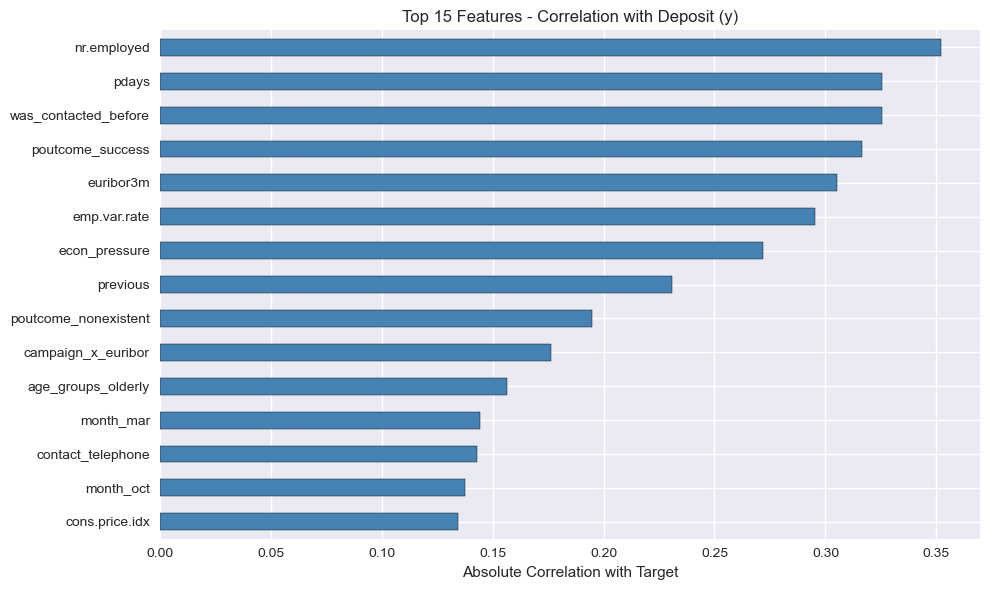

In [41]:
# TODO: visualize top 15 feature correlations with target

top15 = correlations.head(15)

plt.figure(figsize=(10,6))
top15.plot(kind='barh',color='steelblue',edgecolor='black')


plt.xlabel('Absolute Correlation with Target')
plt.title('Top 15 Features - Correlation with Deposit (y)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [42]:
# find pairs with absolute correlation > 0.8
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(X_train.columns)):
    for j in range (i+1, len(X_train.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.8:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))

In [43]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)
high_corr_df

,Feature 1,Feature 2,Correlation
0,campaign,campaign_intensity,0.960202
1,campaign,campaign_x_euribor,0.827786
2,campaign,many_contacts,0.867616
3,pdays,was_contacted_before,-0.999992
4,pdays,poutcome_success,-0.953161
5,previous,poutcome_nonexistent,-0.880023
6,emp.var.rate,euribor3m,0.972178
7,emp.var.rate,nr.employed,0.906551
8,emp.var.rate,econ_pressure,-0.988152
9,euribor3m,nr.employed,0.944953


In [44]:
high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print("Highly correlated feature pairs (>0.8):")
high_corr_df

Highly correlated feature pairs (>0.8):


,Feature 1,Feature 2,Correlation
0,emp.var.rate,euribor3m,0.972178
1,campaign,campaign_intensity,0.960202
2,was_contacted_before,poutcome_success,0.952762
3,euribor3m,nr.employed,0.944953
4,emp.var.rate,nr.employed,0.906551
5,campaign_intensity,campaign_x_euribor,0.871111
6,campaign,many_contacts,0.867616
7,campaign_intensity,many_contacts,0.835451
8,campaign,campaign_x_euribor,0.827786
9,previous,poutcome_nonexistent,-0.880023


In [45]:
high_corr_df.sort_values(by='Feature 1')

,Feature 1,Feature 2,Correlation
1,campaign,campaign_intensity,0.960202
6,campaign,many_contacts,0.867616
8,campaign,campaign_x_euribor,0.827786
5,campaign_intensity,campaign_x_euribor,0.871111
7,campaign_intensity,many_contacts,0.835451
0,emp.var.rate,euribor3m,0.972178
4,emp.var.rate,nr.employed,0.906551
13,emp.var.rate,econ_pressure,-0.988152
3,euribor3m,nr.employed,0.944953
12,euribor3m,econ_pressure,-0.975139


In [46]:
# flatten y_train if needed

y_train_flat = y_train.values.ravel()

In [47]:
campaign_features = ['campaign', 'campaign_intensity', 'campaign_x_euribor', 'many_contacts']
economic_features = ['emp.var.rate', 'euribor3m', 'nr.employed', 'econ_pressure']
contact_features = ['pdays', 'was_contacted_before']

for name, features in [('Campaign', campaign_features), 
                        ('Economic', economic_features),
                        ('Contact', contact_features)]:
    print(f'\n{name} cluster:')
    for col in features:
        corr = abs(X_train[col].corr(pd.Series(y_train_flat, index=X_train.index)))
        print(f'  {col}: {corr:.4f}')


Campaign cluster:
  campaign: 0.0693
  campaign_intensity: 0.1110
  campaign_x_euribor: 0.1764
  many_contacts: 0.0620

Economic cluster:
  emp.var.rate: 0.2951
  euribor3m: 0.3051
  nr.employed: 0.3520
  econ_pressure: 0.2721

Contact cluster:
  pdays: 0.3257
  was_contacted_before: 0.3256


Based on the correlation analysis:
- **Keep** features with meaningful correlation to target
- **Remove** one from each highly correlated pair (keep the one more correlated with target)
- Use domain knowledge + correlation to make final decisions

> **Note:** For this demo, we'll keep all features and let the model handle it. In practice, you may want to drop redundant features to reduce overfitting.

## 6. Handle Class Imbalance (SMOTE)

⚠️ **Critical Rules:**
1. Apply ONLY to **training data** (NEVER to test data!)
2. Apply AFTER all preprocessing and feature engineering
3. Apply INSIDE cross-validation folds in practice

SMOTE = Synthetic Minority Oversampling Technique  
It creates synthetic samples of the minority class by interpolating between existing minority samples.

In [48]:
# TODO: check class distribution before SMOTE

imbalance_ratio = (y_train_flat==0).sum() / (y_train_flat==1).sum()

print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')

Imbalance ratio: 7.9:1


In [49]:
# TODO: apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=4950)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_flat)

In [50]:
print('After SMOTE:')
print(f'  Class 0 (no deposit):  {(y_train_smote == 0).sum():,}')
print(f'  Class 1 (yes deposit): {(y_train_smote == 1).sum():,}')
imbalance_ratio = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()
print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')
print(f'\n  X_train shape: {X_train.shape} → {X_train_smote.shape}')

After SMOTE:
  Class 0 (no deposit):  29,229
  Class 1 (yes deposit): 29,229
Imbalance ratio: 1.0:1

  X_train shape: (32940, 51) → (58458, 51)


In [52]:
print('Before SMOTE:')
print(f'  Class 0 (no deposit):  {(y_train_flat == 0).sum():,}')
print(f'  Class 1 (yes deposit): {(y_train_flat == 1).sum():,}')

Before SMOTE:
  Class 0 (no deposit):  29,229
  Class 1 (yes deposit): 3,711


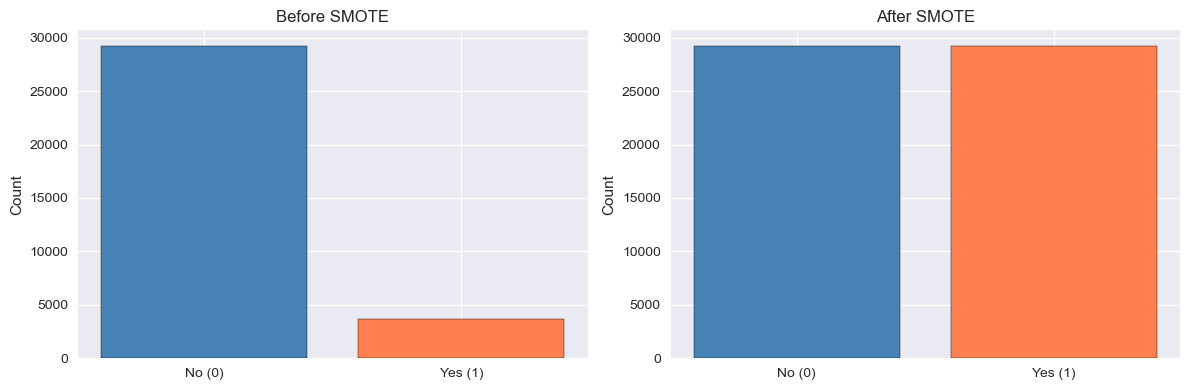

In [53]:
# visualize before vs after SMOTE

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No (0)', 'Yes (1)'], [(y_train_flat==0).sum(), (y_train_flat==1).sum()], 
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

axes[1].bar(['No (0)', 'Yes (1)'], [(y_train_smote==0).sum(), (y_train_smote==1).sum()], 
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 7. Save Final Data for Modeling

We save **two versions** of training data:
- **Without SMOTE** — for models that handle imbalance internally (e.g., `class_weight='balanced'`)
- **With SMOTE** — for models that need balanced data

In [54]:
import os

os.makedirs('../data/modeling', exist_ok=True)

## save WITHOUT SMOTE
X_train.to_csv('../data/modeling/X_train.csv', index=False)
X_test.to_csv('../data/modeling/X_test.csv', index=False)
pd.Series(y_train_flat).to_csv('../data/modeling/y_train.csv', index=False)
y_test.to_csv('../data/modeling/y_test.csv', index=False)

## save WITH SMOTE
X_train_smote.to_csv('../data/modeling/X_train_smote.csv', index=False)
pd.Series(y_train_smote).to_csv('../data/modeling/y_train_smote.csv', index=False)

print('Saved to ../data/modeling/')
print(f'  X_train:       {X_train.shape}')
print(f'  X_train_smote: {X_train_smote.shape}')
print(f'  X_test:        {X_test.shape}')

Saved to ../data/modeling/
  X_train:       (32940, 51)
  X_train_smote: (58458, 51)
  X_test:        (8236, 51)


## Summary

### Feature Created:

- create binning, ratio, interaction, flag features, for example: age_groups, campgain_intensity...

### Processing Applied:
- Ordinal encoded: education
- One-hot encoded: job, marital, contact, month, day_of_week, poutcome, default,age_groups
- Scaled all numerical features
- Handel imbalance ratio with SMOTE (training set)

### Datasets:
- **X_train/y_train** original imbalanced dataset
- **X_train_smote/y_train_smote** balanced for modeling without build-in imbalanced handling
- **X_test/y_test** untouched test sets for final evaluation